# Task 2 – Measure Overlap Intensity (20260323)

For each patent in `focal_terms_20260323.parquet`, count the number of focal terms and analyse the distribution across patents.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('../output/focal_terms_20260323.parquet')
print(f'Total (patent_id, focal_term) pairs : {len(df)}')
print(f'Unique patents                       : {df["patent_id"].nunique()}')
print(f'Unique focal term strings            : {df["focal_term"].nunique()}')
df.head()

Total (patent_id, focal_term) pairs : 19145
Unique patents                       : 14237
Unique focal term strings            : 4611


,patent_id,focal_term,freq_in_patent,freq_in_cited_papers
0,9949959,pirfenidone,1,1
1,10145926,imaging,3,12
2,9869450,50,1,1
3,10076512,lonafarnib,2,3
4,10076512,ritonavir,2,2


## Step 1 – Count focal terms per patent

In [21]:
counts = (
    df.groupby('patent_id')['focal_term']
      .nunique()
      .reset_index(name='num_focal_terms')
)
counts.head(10)

,patent_id,num_focal_terms
0,10000506,1
1,10000699,1
2,10000734,1
3,10000741,1
4,10000800,1
5,10000814,8
6,10001442,1
7,10001614,1
8,10002311,1
9,10002419,1


## Step 2 – Summary statistics

In [22]:
stats = counts['num_focal_terms'].describe()
print('=== Distribution of focal terms per patent ===')
print(stats)
print(f'\nPatents with exactly 1 focal term : {(counts["num_focal_terms"]==1).sum()} ({(counts["num_focal_terms"]==1).mean()*100:.1f}%)')
print(f'Patents with 2+ focal terms       : {(counts["num_focal_terms"]>=2).sum()} ({(counts["num_focal_terms"]>=2).mean()*100:.1f}%)')
print(f'Patents with 5+ focal terms       : {(counts["num_focal_terms"]>=5).sum()} ({(counts["num_focal_terms"]>=5).mean()*100:.1f}%)')

=== Distribution of focal terms per patent ===
count    14237.000000
mean         1.344736
std          0.820161
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         17.000000
Name: num_focal_terms, dtype: float64

Patents with exactly 1 focal term : 11030 (77.5%)
Patents with 2+ focal terms       : 3207 (22.5%)
Patents with 5+ focal terms       : 131 (0.9%)


## Step 3 – Visualizations

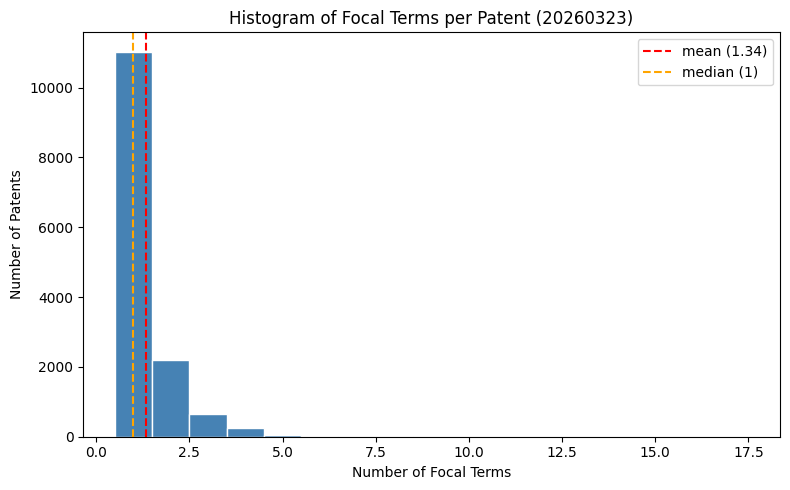

In [23]:
mean_val   = counts['num_focal_terms'].mean()
median_val = counts['num_focal_terms'].median()

# Histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(counts['num_focal_terms'], bins=range(1, counts['num_focal_terms'].max() + 2),
        color='steelblue', edgecolor='white', align='left')
ax.axvline(mean_val,   color='red',    linestyle='--', label=f'mean ({mean_val:.2f})')
ax.axvline(median_val, color='orange', linestyle='--', label=f'median ({median_val:.0f})')
ax.set_title('Histogram of Focal Terms per Patent (20260323)')
ax.set_xlabel('Number of Focal Terms')
ax.set_ylabel('Number of Patents')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/histogram_focal_terms_20260323.png', dpi=150)
plt.show()

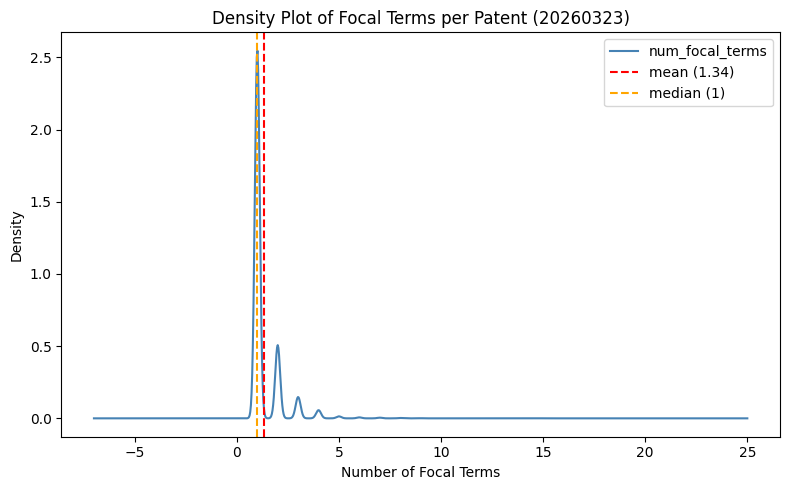

In [24]:
# Density plot
fig, ax = plt.subplots(figsize=(8, 5))
counts['num_focal_terms'].plot.kde(ax=ax, color='steelblue')
ax.axvline(mean_val,   color='red',    linestyle='--', label=f'mean ({mean_val:.2f})')
ax.axvline(median_val, color='orange', linestyle='--', label=f'median ({median_val:.0f})')
ax.set_title('Density Plot of Focal Terms per Patent (20260323)')
ax.set_xlabel('Number of Focal Terms')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.savefig('../visualizations/density_focal_terms_20260323.png', dpi=150)
plt.show()

## Step 4 – Examples

In [25]:
min_val = int(stats['min'])
max_val = int(stats['max'])

# Min example
pid_min = counts[counts['num_focal_terms'] == min_val].iloc[0]['patent_id']
terms_min = df[df['patent_id'] == pid_min]['focal_term'].tolist()
print(f'Patent {pid_min} (min = {min_val} focal term): {terms_min}')

# Typical example (3-5 focal terms)
pid_mid = counts[counts['num_focal_terms'].between(3, 5)].iloc[0]['patent_id']
n_mid   = counts[counts['num_focal_terms'].between(3, 5)].iloc[0]['num_focal_terms']
terms_mid = df[df['patent_id'] == pid_mid]['focal_term'].tolist()
print(f'Patent {pid_mid} (typical = {n_mid} focal terms): {terms_mid}')

# Max example
pid_max = counts[counts['num_focal_terms'] == max_val].iloc[0]['patent_id']
terms_max = df[df['patent_id'] == pid_max]['focal_term'].tolist()
print(f'Patent {pid_max} (max = {max_val} focal terms): {terms_max}')

Patent 10000506 (min = 1 focal term): ['thienopyridine']
Patent 10004742 (typical = 5 focal terms): ['lapatinib', 'trastuzumab', 'capecitabine', 'paclitaxel', 'letrozole']
Patent 8486991 (max = 17 focal terms): ['non-nucleoside', 'co-receptor', 'amprenavir', 'indinavir', 'saquinavir', 'nelfinavir', 'lamivudine', 'abacavir', 'zalcitabine', 'zidovudine', 'tenofovir', 'didanosine', 'stavudine', 'delavirdine', 'efavirenz', 'nevirapine', 'enfuvirtide']
